In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

In [2]:
# ------------------------------
# Configuration
# ------------------------------
seilora_ranks = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
metrics = {"OvU" : "Over vs Under",
           "UvN": "Under vs None",
           "OvN": "Over vs None"
           }

caqtl_datasets = {
    "A" : "GTEX Outliers",
    "B" : "CAGI5 Saturation",
    "C" : "MPRA Saturation",
    "D" : "GTEX eQTLS",
    "E" : "MPRA eQTLS",
    "F" : "UKBB Proteome",
    "G" : "Gel RNA"
}

dataset_order = ["D", "A", "B", "C", "E", "F", "G"]

files = {
    "Sei-LLRA": "benchmark_pai_seilora.tsv",
    "Borzoi-LLRA": "borzoi_fixed_benchmark_promoterai.tsv",
    "Enformer-LLRA": "enformer_fixed_benchmark_promoterai.tsv",
}

full_enformer_borzoi_file = "grelu_benchmark_promoterai.tsv"

seilora_model_names = {
    "seilora_1_None_no_quant": "Sei-LLRA\nrank=1",
    "seilora_2_None_no_quant": "Sei-LLRA\nrank=2",
    "seilora_4_None_no_quant": "Sei-LLRA\nrank=4",
    "seilora_8_None_no_quant": "Sei-LLRA\nrank=8",
    "seilora_16_None_no_quant": "Sei-LLRA\nrank=16",
    "seilora_32_None_no_quant": "Sei-LLRA\nrank=32",
    "seilora_64_None_no_quant": "Sei-LLRA\nrank=64",
    "seilora_128_None_no_quant": "Sei-LLRA\nrank=128",
    "seilora_256_None_no_quant": "Sei-LLRA\nrank=256",
    "seilora_512_None_no_quant": "Sei-LLRA\nrank=512",
    "seilora_full_None_no_quant": "Sei",
}
borzoilora_model_names = {
    "borzoi_lora_lr1_crfull_None_no_quant": "Borzoi-LLRA\nrank=1",
    "borzoi_lora_lr2_crfull_None_no_quant": "Borzoi-LLRA\nrank=2",
    "borzoi_lora_lr4_crfull_None_no_quant": "Borzoi-LLRA\nrank=4",
    "borzoi_lora_lr8_crfull_None_no_quant": "Borzoi-LLRA\nrank=8",
    "borzoi_lora_lr16_crfull_None_no_quant": "Borzoi-LLRA\nrank=16",
    "borzoi_lora_lr32_crfull_None_no_quant": "Borzoi-LLRA\nrank=32",
    "borzoi_lora_lr64_crfull_None_no_quant": "Borzoi-LLRA\nrank=64",
    "borzoi_lora_lr128_crfull_None_no_quant": "Borzoi-LLRA\nrank=128",
    "borzoi_lora_lr256_crfull_None_no_quant": "Borzoi-LLRA\nrank=256",
    "borzoi_lora_lr512_crfull_None_no_quant": "Borzoi-LLRA\nrank=512",
    "borzoi_lora_lrfull_crfull_None_no_quant": "Borzoi",
}
enformerlora_model_names = {
    "enformer_lora_lr1_crfull_None_no_quant": "Enformer-LLRA\nrank=1",
    "enformer_lora_lr2_crfull_None_no_quant": "Enformer-LLRA\nrank=2",
    "enformer_lora_lr4_crfull_None_no_quant": "Enformer-LLRA\nrank=4",
    "enformer_lora_lr8_crfull_None_no_quant": "Enformer-LLRA\nrank=8",
    "enformer_lora_lr16_crfull_None_no_quant": "Enformer-LLRA\nrank=16",
    "enformer_lora_lr32_crfull_None_no_quant": "Enformer-LLRA\nrank=32",
    "enformer_lora_lr64_crfull_None_no_quant": "Enformer-LLRA\nrank=64",
    "enformer_lora_lr128_crfull_None_no_quant": "Enformer-LLRA\nrank=128",
    "enformer_lora_lr256_crfull_None_no_quant": "Enformer-LLRA\nrank=256",
    "enformer_lora_lr512_crfull_None_no_quant": "Enformer-LLRA\nrank=512",
    "enformer_lora_lrfull_crfull_None_no_quant": "Enformer",
}



In [3]:
dfs = {}
for model_name, file in files.items():
    df = pd.read_csv(file, sep="\t", index_col=0, header=0)
    for row_name in df.index:
        if (
            row_name not in seilora_model_names
            and row_name not in borzoilora_model_names
            and row_name not in enformerlora_model_names
        ):
            #remove from dataframe
            df = df.drop(row_name)
    dfs[model_name] = df


In [4]:
dataset_labels = ["A", "B", "C", "D", "E", "F", "G"]

# Fix invalid colors in caqtl_colora
dataset_colors = {
    "A": "#1D1DF2",
    "B": "#FF8000",
    "C": "#FFAA49",  # replaced 'lightorange' with 'orange'
    "D": "#407AF6",
    "E": "#8FBAFF",
    "F": "#63B455",
    "G": "#A168E2"
}

cols_per_metric_block = len(dataset_order)

model_order = list(dfs.keys())  # ['SeiLora','BorzoiLora','EnformerLora']
model_name_maps = {
    "Sei-LLRA": seilora_model_names,
    "Borzoi-LLRA": borzoilora_model_names,
    "Enformer-LLRA": enformerlora_model_names,
}

def extract_rank(name):
    # Try to find any number in the string (covers seilora_1..., borzoi lr1..., enformer lr1...)
    m = re.search(r'(\d+)', name)
    if m:
        return int(m.group(1))
    if 'full' in name:
        return 'full'  # Now treating as categorical
    return None

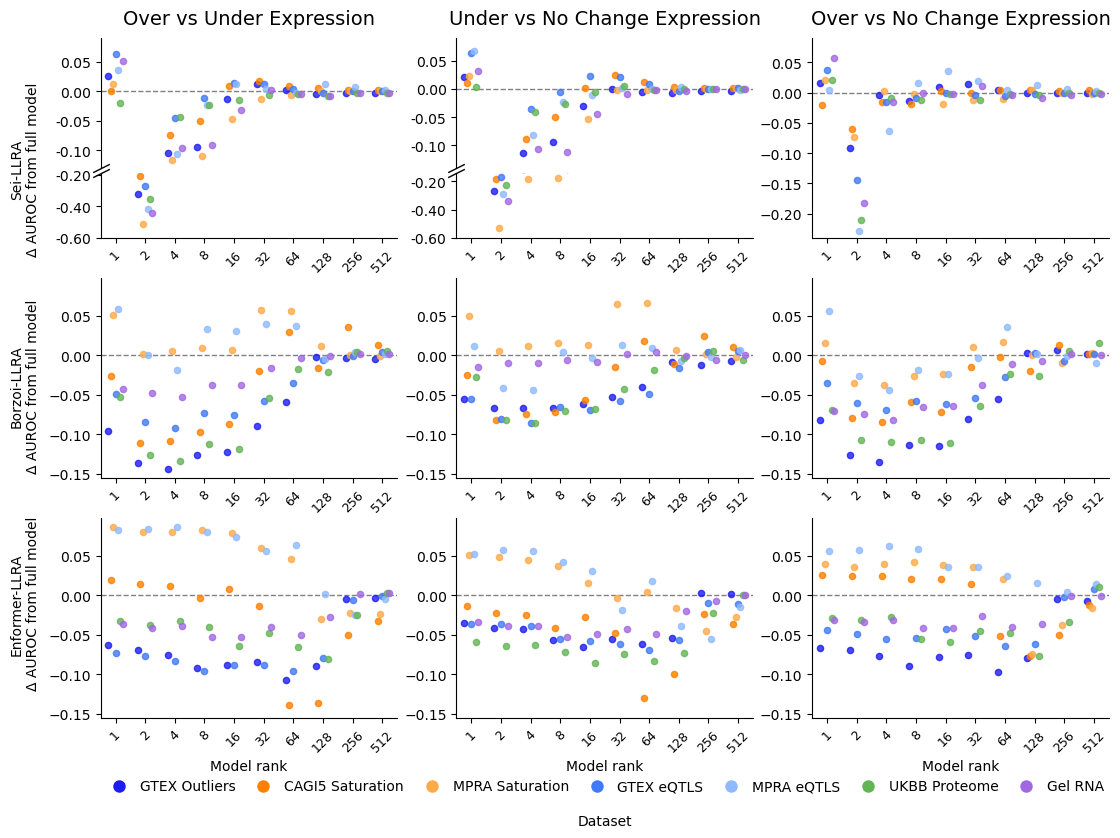

In [5]:
# 3x3 grid of boxplots: signed AUROC difference between rank and full (rank - full)
# x-axis: model rank, y-axis: Δ AUROC (rank - full), points colored by dataset, boxes clear
metrics_keys = list(metrics.keys())
model_order = list(dfs.keys())

fig = plt.figure(figsize=(12.6, 8))

# Use nested GridSpec to have different hspace for different sections
# Outer grid: 3 rows (broken axis section, row1, row2)
outer_gs = fig.add_gridspec(3, 1, height_ratios=[3, 3, 3], hspace=0.2)

# Inner grid for the broken axis section (row 0) - small hspace
inner_gs_row0 = outer_gs[0].subgridspec(2, len(metrics_keys), hspace=0.05, wspace=0.2, height_ratios=[2, 1])

# Row 0 will have two axes per column for columns 0 and 1 (broken axis)
# Column 2 will span both rows (no break)
axes_row0_top = []
axes_row0_bottom = []
for j in range(len(metrics_keys)):
    if j < 2:  # Columns 0 and 1 have broken axes
        ax_top = fig.add_subplot(inner_gs_row0[0, j])
        ax_bottom = fig.add_subplot(inner_gs_row0[1, j], sharex=ax_top)
        axes_row0_top.append(ax_top)
        axes_row0_bottom.append(ax_bottom)
    else:  # Column 2 has no break - span both rows
        ax = fig.add_subplot(inner_gs_row0[:, j])
        axes_row0_top.append(ax)
        axes_row0_bottom.append(None)

# Row 1 and Row 2 - separate grids
inner_gs_row1 = outer_gs[1].subgridspec(1, len(metrics_keys), wspace=0.2)
inner_gs_row2 = outer_gs[2].subgridspec(1, len(metrics_keys), wspace=0.2)

# For rows 1 and 2, share y-axis
_shared_ax = None
axes_row1 = []
for j in range(len(metrics_keys)):
    if _shared_ax is None:
        ax = fig.add_subplot(inner_gs_row1[0, j])
        _shared_ax = ax
    else:
        ax = fig.add_subplot(inner_gs_row1[0, j], sharey=_shared_ax)
    axes_row1.append(ax)

axes_row2 = []
for j in range(len(metrics_keys)):
    ax = fig.add_subplot(inner_gs_row2[0, j], sharey=_shared_ax)
    axes_row2.append(ax)

axes = [None, axes_row1, axes_row2]

# Define break parameters for each column in row 0
BREAK_PARAMS = {
    0: {'break_top': -0.13, 'break_bottom': -0.19, 'outlier_min': -0.6},
    1: {'break_top': -0.14, 'break_bottom': -0.14, 'outlier_min': -0.6},
    2: None
}

# Create fixed, ordered horizontal offsets per dataset
n_datasets = len(dataset_labels)
_dataset_base_offsets = np.linspace(-(n_datasets - 1) / 2.0, (n_datasets - 1) / 2.0, n_datasets) * 0.08
dataset_offsets = {ds: float(off) for ds, off in zip(dataset_labels, _dataset_base_offsets)}

_orig_random_normal = np.random.normal

def _fixed_random_normal(*args, **kwargs):
    if len(args) >= 3:
        loc, scale, size = args[0], args[1], args[2]
    else:
        loc = kwargs.get('loc', args[0] if len(args) >= 1 else 0.0)
        scale = kwargs.get('scale', args[1] if len(args) >= 2 else 1.0)
        size = kwargs.get('size', None)

    if size is None:
        return _orig_random_normal(loc=loc, scale=scale)
    if isinstance(size, tuple):
        return _orig_random_normal(loc=loc, scale=scale, size=size)

    try:
        n = int(size)
    except Exception:
        return _orig_random_normal(loc=loc, scale=scale, size=size)

    offs = _dataset_base_offsets[:n].astype(float)
    return np.array([loc + o for o in offs])

np.random.normal = _fixed_random_normal

# Get the 'full' score for each model/metric/dataset combination
full_scores = {}
for model in model_order:
    df_model = dfs[model]
    full_scores[model] = {}

    map_dict = model_name_maps.get(model, {})
    full_row = None
    for k, v in map_dict.items():
        if 'rank=full' in v.replace(' ', '').lower() and k in df_model.index:
            full_row = k
            break

    if full_row is None:
        for row in df_model.index:
            rl = row.lower()
            if 'lrfull' in rl or rl.endswith('_full') or rl.startswith('full') or rl == 'full':
                full_row = row
                break

    if full_row is None:
        for row in df_model.index:
            rl = row.lower()
            if 'full' in rl and 'crfull' not in rl and 'cr_full' not in rl:
                full_row = row
                break

    if full_row is None:
        continue

    for j, metric_key in enumerate(metrics_keys):
        full_scores[model][metric_key] = {}
        for ds in dataset_labels:
            pos = dataset_order.index(ds)
            col_index = pos + j * cols_per_metric_block
            col_name = df_model.columns[col_index]
            full_scores[model][metric_key][ds] = float(df_model.loc[full_row, col_name])

# Create legend handles
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                           label=caqtl_datasets[ds], markersize=10) 
                 for ds, color in dataset_colors.items()]

# Add column subtitles
col_subtitles = ['Over vs Under Expression', 'Under vs No Change Expression', 'Over vs No Change Expression']
for j, subtitle in enumerate(col_subtitles):
    axes_row0_top[j].set_title(subtitle, fontsize=14, pad=10)

for i, model in enumerate(model_order):
    df_model = dfs[model]
    map_dict = model_name_maps[model]

    for j, metric_key in enumerate(metrics_keys):
        
        # Collect data
        rank_diffs = {}
        for row_name in df_model.index:
            rank = extract_rank(row_name)
            if rank == 'full' or rank is None:
                continue

            rank_diffs.setdefault(rank, {})
            for ds in dataset_labels:
                pos = dataset_order.index(ds)
                col_index = pos + j * cols_per_metric_block
                col_name = df_model.columns[col_index]

                rank_score = float(df_model.loc[row_name, col_name])
                full_score = full_scores.get(model, {}).get(metric_key, {}).get(ds, np.nan)
                diff = rank_score - full_score
                rank_diffs[rank][ds] = diff

        if not rank_diffs:
            continue

        ranks = sorted(rank_diffs.keys())

        boxplot_data = []
        data_colors = []
        for rank in ranks:
            diffs = []
            colors = []
            for ds in dataset_labels:
                diff = rank_diffs[rank].get(ds, np.nan)
                if not np.isnan(diff):
                    diffs.append(diff)
                    colors.append(dataset_colors[ds])
            boxplot_data.append(diffs)
            data_colors.append(colors)

        if i == 0:
            # Row 0 - may have broken axis depending on column
            break_params = BREAK_PARAMS.get(j)
            
            if break_params is not None:
                # BROKEN AXIS
                ax_top = axes_row0_top[j]
                ax_bottom = axes_row0_bottom[j]
                
                break_top = break_params['break_top']
                break_bottom = break_params['break_bottom']
                outlier_min = break_params['outlier_min']
                
                ax_top.set_ylim(break_top, 0.09)
                ax_bottom.set_ylim(outlier_min, break_bottom)
                
                for ax in [ax_top, ax_bottom]:
                    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
                    ax.set_xlim(-0.5, max(0, len(ranks) - 0.5))
                    
                    for k, (values, colors) in enumerate(zip(boxplot_data, data_colors)):
                        y = np.array(values)
                        if len(y) == 0:
                            continue
                        x = np.random.normal(k, 0.05, size=len(y))
                        for xi, yi, color in zip(x, y, colors):
                            ax.scatter(xi, yi, color=color, s=20, zorder=3, alpha=0.8)
                
                ax_top.spines.bottom.set_visible(False)
                ax_bottom.spines.top.set_visible(False)
                ax_top.spines.top.set_visible(False)
                ax_top.spines.right.set_visible(False)
                ax_bottom.spines.right.set_visible(False)
                
                ax_top.tick_params(bottom=False, labelbottom=False)
                ax_bottom.xaxis.tick_bottom()
                
                ax_bottom.set_xticks(np.arange(len(ranks)))
                ax_bottom.set_xticklabels([str(r) for r in ranks], rotation=45, fontsize=9)
                if j == 0:
                    top_ticks = [0.05, 0.0, -0.05, -0.10]
                elif j == 1:
                    top_ticks = [0.05, 0.0, -0.05, -0.10]
                ax_top.set_yticks(top_ticks)
                ax_top.set_yticklabels([f'{t:.2f}' for t in top_ticks])
                
                bottom_ticks = np.arange(outlier_min, break_bottom, 0.2)
                ax_bottom.set_yticks(bottom_ticks)
                ax_bottom.set_yticklabels([f'{t:.2f}' for t in bottom_ticks])
                
                d = .5
                kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
                              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
                ax_top.plot([0], [0], transform=ax_top.transAxes, **kwargs)
                ax_bottom.plot([0], [1], transform=ax_bottom.transAxes, **kwargs)
            
            else:
                # NO BREAK (column 2)
                ax = axes_row0_top[j]
                
                ax.axhline(0, color="grey", linestyle="--", linewidth=1)
                ax.set_xlim(-0.5, max(0, len(ranks) - 0.5))
                
                for k, (values, colors) in enumerate(zip(boxplot_data, data_colors)):
                    y = np.array(values)
                    if len(y) == 0:
                        continue
                    x = np.random.normal(k, 0.05, size=len(y))
                    for xi, yi, color in zip(x, y, colors):
                        ax.scatter(xi, yi, color=color, s=20, zorder=3, alpha=0.8)
                
                ax.set_xticks(np.arange(len(ranks)))
                ax.set_xticklabels([str(r) for r in ranks], rotation=45, fontsize=9)
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)
                ax.set_ylim(-0.24, 0.09)
        
        else:
            # Normal rows (1 and 2)
            ax = axes[i][j]
            
            ax.axhline(0, color="grey", linestyle="--", linewidth=1)
            ax.set_xlim(-0.5, max(0, len(ranks) - 0.5))

            for k, (values, colors) in enumerate(zip(boxplot_data, data_colors)):
                y = np.array(values)
                if len(y) == 0:
                    continue
                x = np.random.normal(k, 0.05, size=len(y))
                for xi, yi, color in zip(x, y, colors):
                    ax.scatter(xi, yi, color=color, s=20, zorder=3, alpha=0.8)

            ax.set_xticks(np.arange(len(ranks)))
            ax.set_xticklabels([str(r) for r in ranks], rotation=45, fontsize=9)
            
            if i == 2:
                ax.set_xlabel("Model rank")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

# Add row labels using fig.text at fixed x position, aligned to each row's center
# Get the vertical centers of each row section
row0_top_pos = axes_row0_top[0].get_position()
row0_bottom_pos = axes_row0_bottom[0].get_position()
row0_center_y = (row0_top_pos.y1 + row0_bottom_pos.y0) / 2 

row1_pos = axes_row1[0].get_position()
row1_center_y = (row1_pos.y0 + row1_pos.y1) / 2 

row2_pos = axes_row2[0].get_position()
row2_center_y = (row2_pos.y0 + row2_pos.y1) / 2 

# Add model names as row labels
fig.text(0.04, row0_center_y, f"{model_order[0]}\nΔ AUROC from full model", 
         va='center', ha='center', rotation=90, fontsize=10)
fig.text(0.04, row1_center_y, f"{model_order[1]}\nΔ AUROC from full model", 
         va='center', ha='center', rotation=90, fontsize=10)
fig.text(0.04, row2_center_y, f"{model_order[2]}\nΔ AUROC from full model", 
         va='center', ha='center', rotation=90, fontsize=10)

# Adjust left margin to make room for labels
plt.subplots_adjust(left=0.10, top=0.93, bottom=0.08)

# Add legend
legend = fig.legend(handles=legend_handles,
                    loc='lower center', bbox_to_anchor=(0.5, -0.03),
                    ncol=len(legend_handles), frameon=False,
                    fontsize=10,
                    handletextpad=0.5,
                    columnspacing=1.0) 

fig.text(0.5, -0.04, 'Dataset', ha='center', va='top', fontsize=10)

plt.savefig('../figs/fig2_boxplot_grid_alt_cut', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
full_model_rows = {
    "Sei": "seilora_full_None_no_quant",
    "Borzoi": "borzoi_lora_lrfull_crfull_None_no_quant",
    "Enformer": "enformer_lora_lrfull_crfull_None_no_quant",
}

metrics_keys = ['OvU', 'UvN', 'OvN']

dataset_file_order = ["D", "A", "B", "C", "E", "F", "G"]
dataset_display_order = sorted(dataset_file_order)

additional_models_file = "./benchmark_pai_sota.tsv"
new_models_df = pd.read_csv(additional_models_file, sep=r"\s+", engine='python')

new_models_data = {}
for _, row in new_models_df.iterrows():
    model_name = row["model"]
    values = row.drop("model").values.astype(float)
    new_models_data[model_name] = (
        values.reshape(len(metrics_keys), len(dataset_file_order))
              .T
    )

all_values = []

for model_name in full_model_rows.keys():
    df_model = dfs[model_name + "-LLRA"]
    for row_name in [full_model_rows[model_name]]:
        if row_name in df_model.index:
            for ds in dataset_file_order:
                for j in range(len(metrics_keys)):
                    pos = dataset_file_order.index(ds)
                    col_index = pos + j * cols_per_metric_block
                    all_values.append(
                        float(df_model.loc[row_name, df_model.columns[col_index]])
                    )

for model_vals in new_models_data.values():
    all_values.extend(model_vals.flatten())

vmin, vmax = np.min(all_values), np.max(all_values)


/var/folders/m7/dmsq22ys4vdbpb0j27w6prv40000gn/T/ipykernel_26255/1958611037.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


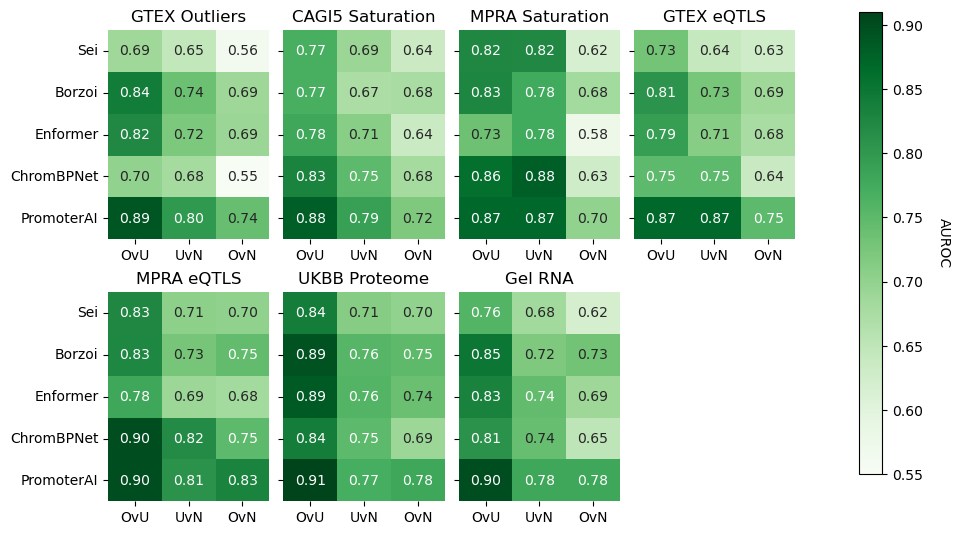

In [7]:
# Original dataset order in data (columns are correct)
dataset_order = ["D", "A", "B", "C", "E", "F", "G"]
# Define the subplot order (A → G)
plot_order = ["A", "B", "C", "D", "E", "F", "G"]
# Map plot_order to axis indices
plot_indices = [dataset_order.index(ds) for ds in plot_order]

# Plot 2 rows × 4 columns
fig, axes = plt.subplots(2, 4, figsize=(10, 6), sharey=True)
axes = axes.flatten()

# Variable to store the last mappable for colorbar
last_mappable = None

for plot_idx, ds in enumerate(plot_order):
    orig_idx = dataset_order.index(ds)  # index in original data
    heatmap_data = []
    
    # Existing LoRA full models
    for model_name, full_row_name in full_model_rows.items():
        df_model = dfs[model_name + "-LLRA"]
        if full_row_name not in df_model.index:
            heatmap_data.append([float('nan')] * len(metrics_keys))
            continue
        
        row_values = []
        for j, metric_key in enumerate(metrics_keys):
            col_index = orig_idx + j * cols_per_metric_block
            col_name = df_model.columns[col_index]
            row_values.append(float(df_model.loc[full_row_name, col_name]))
        heatmap_data.append(row_values)
    
    # New models
    for model_name in new_models_df["model"]:
        row_values = new_models_data[model_name][orig_idx, :].tolist()
        heatmap_data.append(row_values)
    
    row_labels = list(full_model_rows.keys()) + list(new_models_df["model"])
    heatmap_df = pd.DataFrame(heatmap_data, index=row_labels, columns=metrics_keys)
    
    # Create heatmap without individual colorbars
    im = sns.heatmap(
        heatmap_df,
        ax=axes[plot_idx],
        annot=True,
        fmt=".2f",
        cmap="Greens",
        vmin=vmin,
        vmax=vmax,
        cbar=False  # Disable individual colorbars
    )
    
    # Store the last mappable for the colorbar
    last_mappable = im.get_children()[0]
    
    axes[plot_idx].set_title(caqtl_datasets[ds], fontsize=12)
    axes[plot_idx].set_ylabel("")

# Hide the 8th subplot (last one in 2x4 grid)
axes[7].set_visible(False)

# Add a single colorbar on the right side spanning both rows
cbar = fig.colorbar(last_mappable, ax=axes.tolist(), 
                    fraction=0.046, pad=0.04)
cbar.set_label('AUROC', rotation=270, labelpad=20)

plt.tight_layout()
plt.subplots_adjust(top=0.85, right = 0.8)
plt.savefig('../figs/fig2_full_models_with_new_heatmaps_v2.png', dpi=300)
plt.show()